In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data
from src.eda_utils import *

In [5]:
df = load_data("../data/insurance_data.csv")
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [6]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  object 
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  object 
 3   Province             10000 non-null  object 
 4   VehicleType          10000 non-null  object 
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [8]:
df.dtypes

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df['TransactionMonth'] = (
    df['TransactionDate']
    .dt.to_period('M')
)

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Series([], dtype: int64)

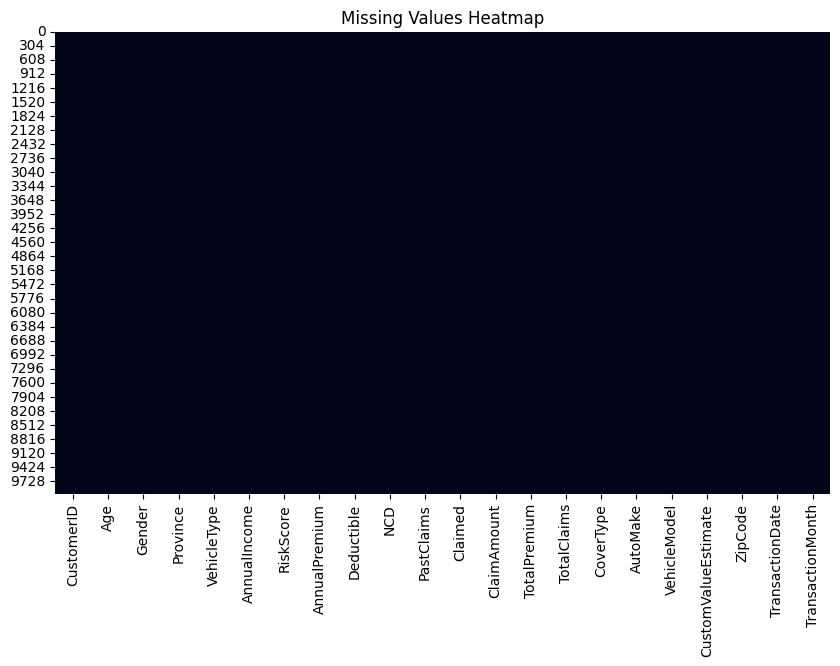

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

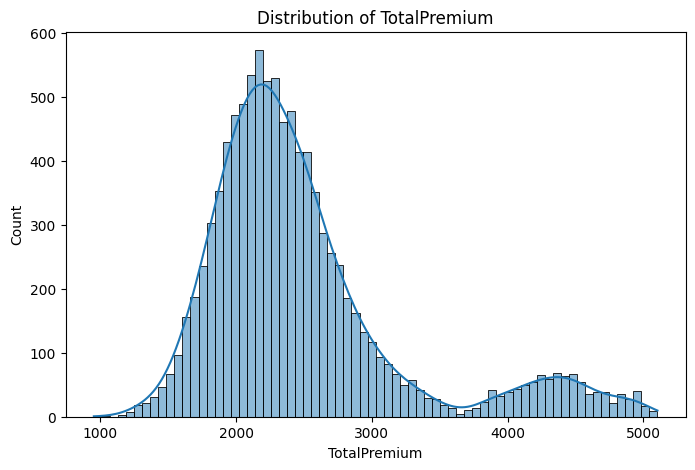

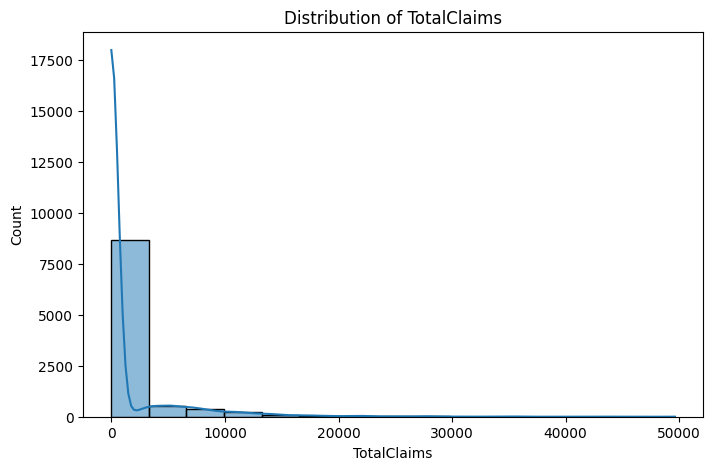

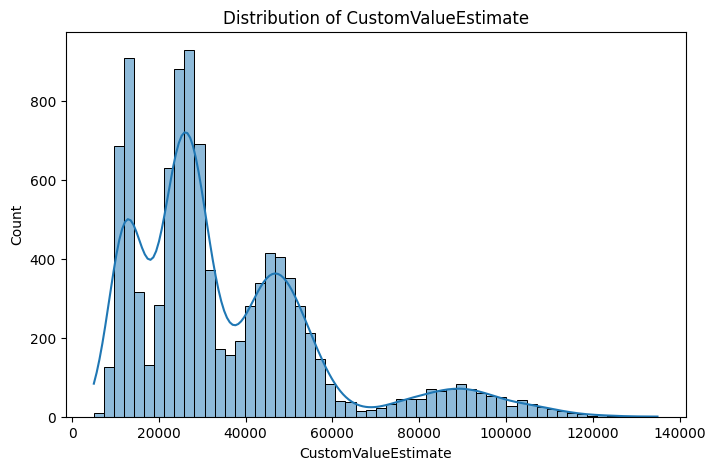

In [11]:
plot_histogram(df, 'TotalPremium')
plot_histogram(df, 'TotalClaims')
plot_histogram(df, 'CustomValueEstimate')

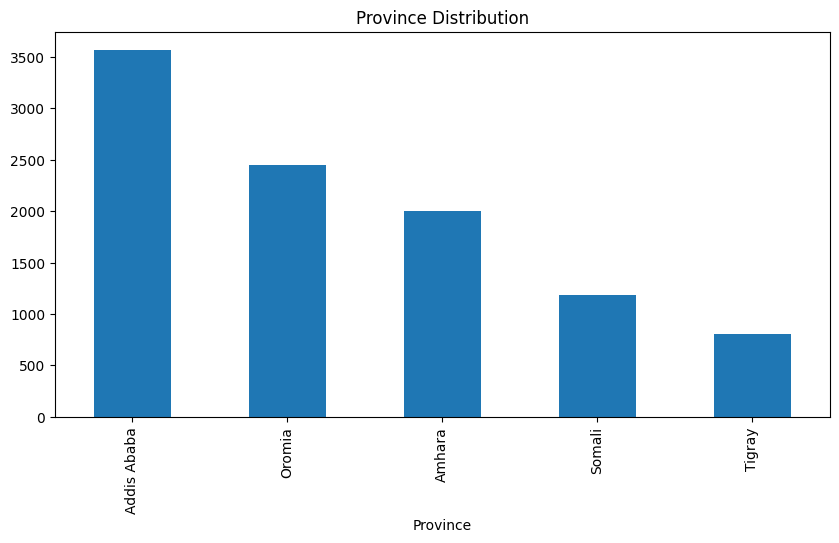

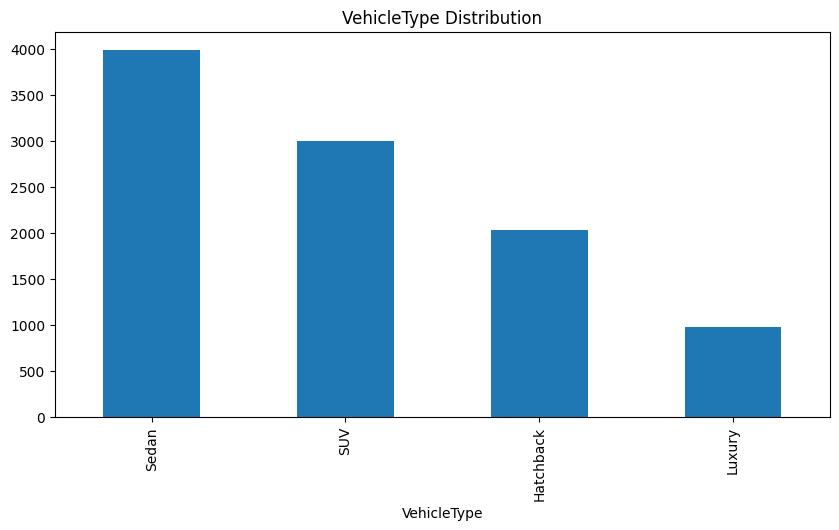

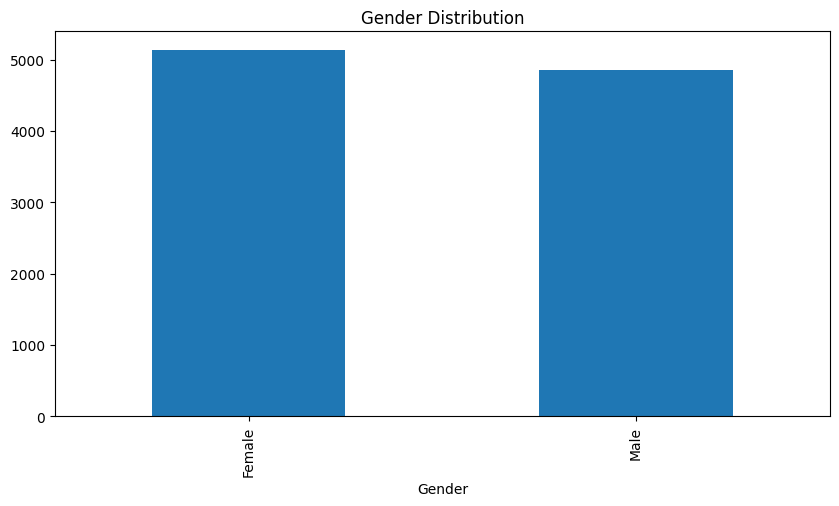

In [12]:
plot_bar(df, 'Province')
plot_bar(df, 'VehicleType')
plot_bar(df, 'Gender')

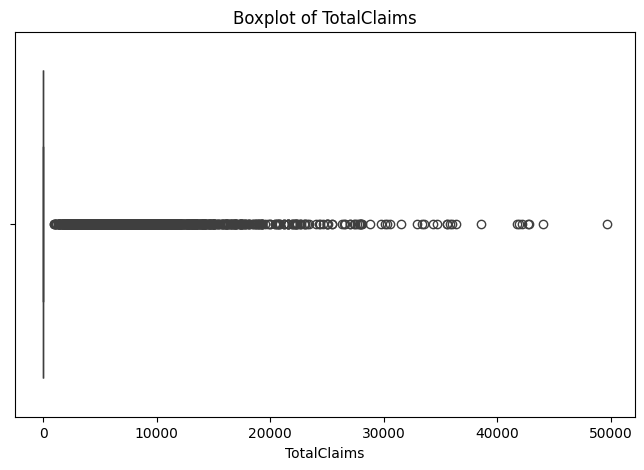

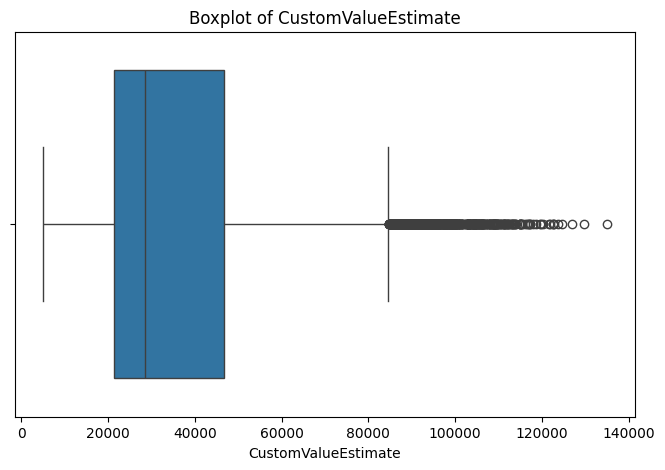

In [13]:
plot_box(df, 'TotalClaims')
plot_box(df, 'CustomValueEstimate')

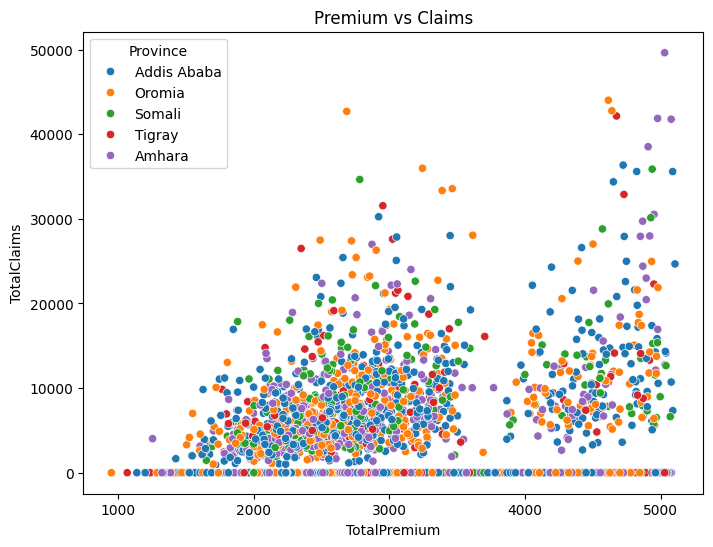

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims',
    hue='Province'
)

plt.title("Premium vs Claims")
plt.show()

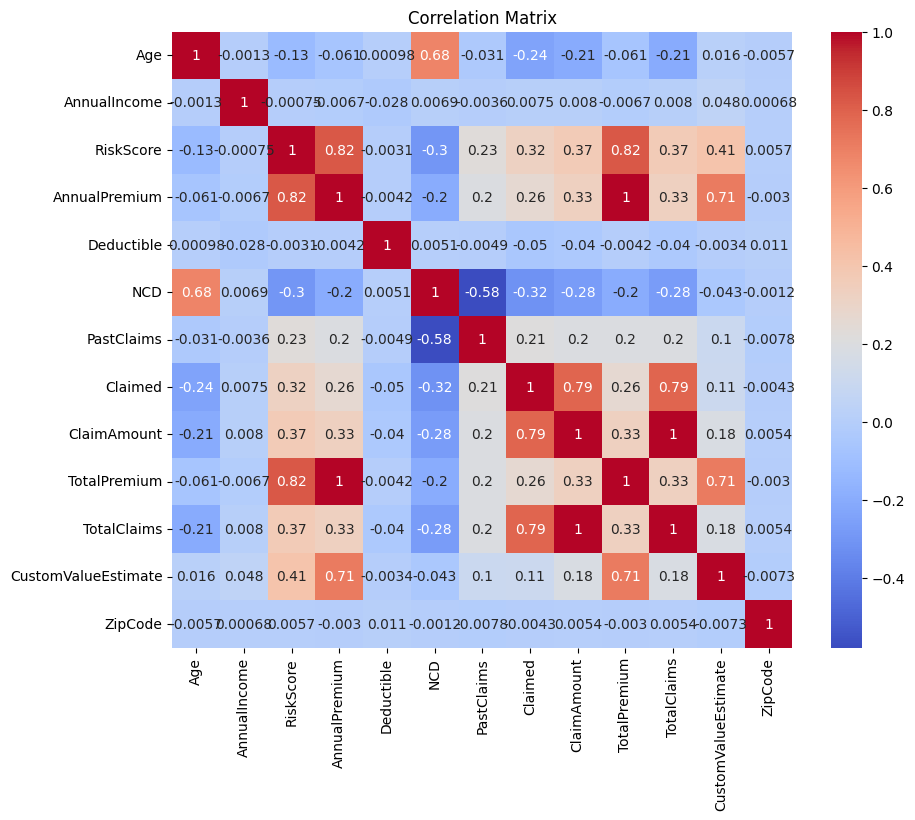

In [15]:
correlation_heatmap(df)

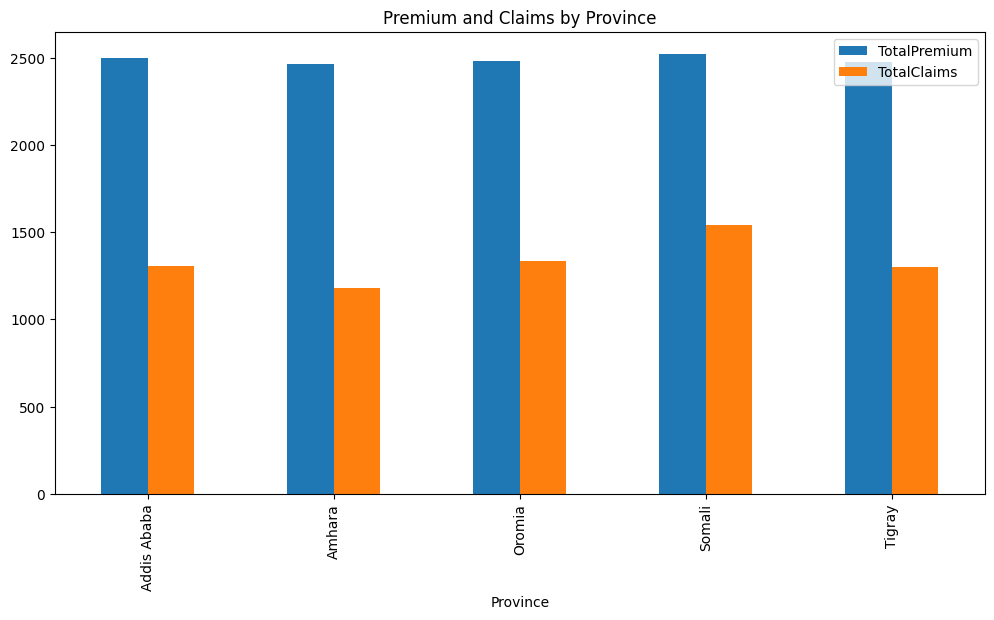

In [16]:
province_summary = df.groupby('Province')[
    ['TotalPremium', 'TotalClaims']
].mean()

province_summary.plot(kind='bar', figsize=(12,6))
plt.title("Premium and Claims by Province")
plt.show()

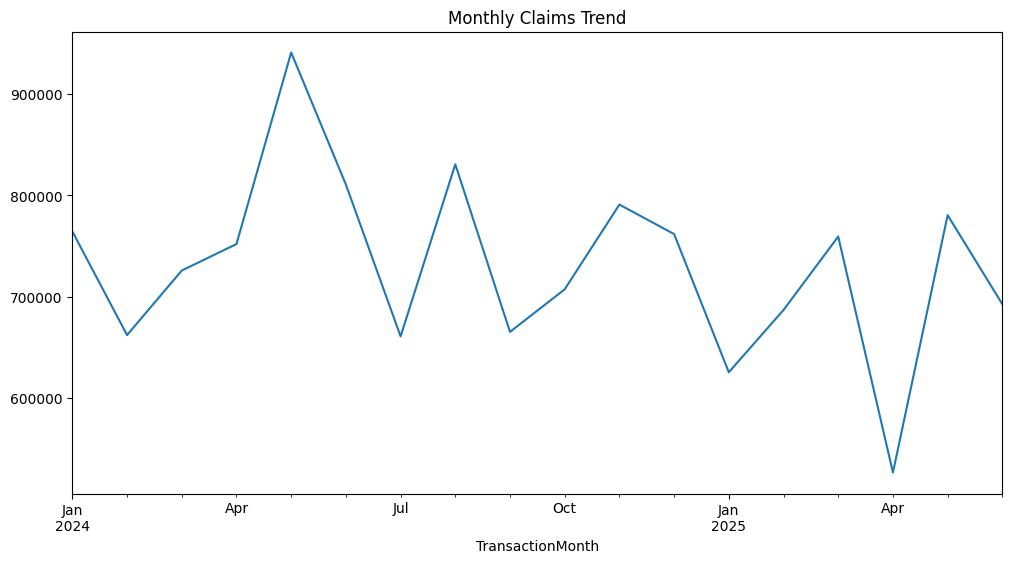

In [18]:
monthly_claims = df.groupby('TransactionMonth')[
    'TotalClaims'
].sum()

monthly_claims.plot(figsize=(12,6))
plt.title("Monthly Claims Trend")
plt.show()

In [19]:
loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print("Overall Loss Ratio:", loss_ratio)

Overall Loss Ratio: 0.5281836596904845


In [20]:
province_lr = df.groupby('Province').apply(
    lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
)

province_lr.sort_values(ascending=False)

/tmp/ipykernel_15161/3494975603.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  province_lr = df.groupby('Province').apply(


Province
Somali         0.611927
Oromia         0.537272
Tigray         0.526016
Addis Ababa    0.522400
Amhara         0.477600
dtype: float64

In [22]:
vehicle_claims = df.groupby('AutoMake')[
    'TotalClaims'
].mean().sort_values()

vehicle_claims.tail(10)
vehicle_claims.tail(10)
vehicle_claims.head(10)

AutoMake
Lifan             918.103987
Hyundai          1042.739272
Suzuki           1122.025761
Toyota           1372.520878
BMW              3362.890855
Mercedes-Benz    3787.012618
Name: TotalClaims, dtype: float64

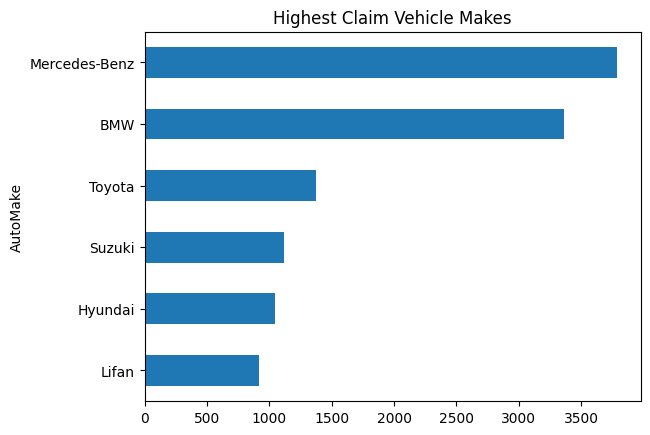

In [23]:
vehicle_claims.tail(10).plot(kind='barh')
plt.title("Highest Claim Vehicle Makes")
plt.show()

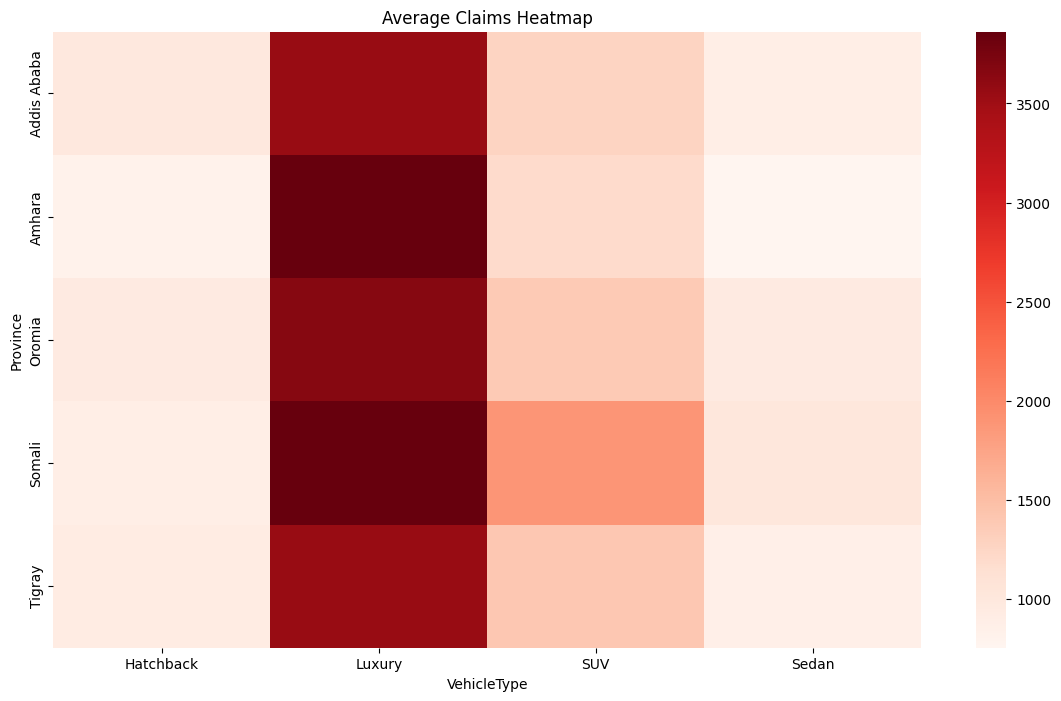

In [24]:
pivot = pd.pivot_table(
    df,
    values='TotalClaims',
    index='Province',
    columns='VehicleType',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='Reds')
plt.title("Average Claims Heatmap")
plt.show()

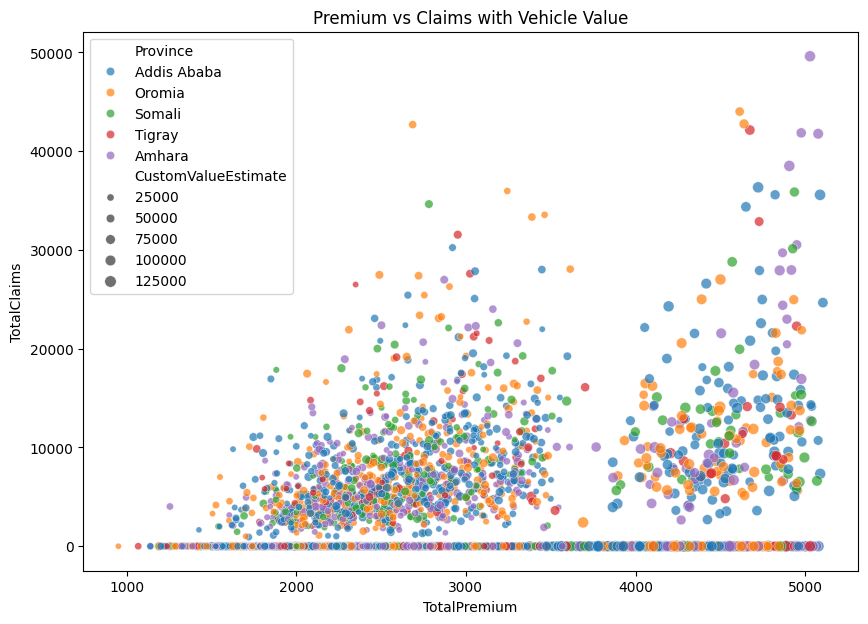

In [25]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims',
    size='CustomValueEstimate',
    hue='Province',
    alpha=0.7
)

plt.title("Premium vs Claims with Vehicle Value")
plt.show()

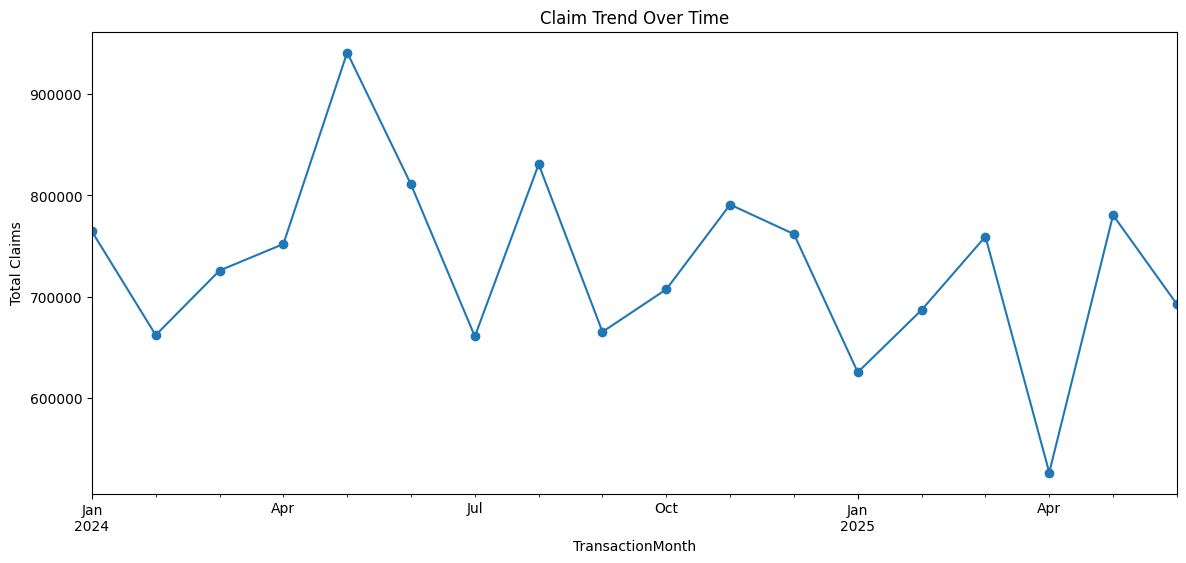

In [26]:
monthly_claims.plot(
    figsize=(14,6),
    marker='o'
)

plt.title("Claim Trend Over Time")
plt.ylabel("Total Claims")
plt.show()

Loss Ratio by Vehicle Type:
 VehicleType
Luxury       0.842422
SUV          0.563729
Hatchback    0.420163
Sedan        0.404001
dtype: float64

Loss Ratio by Gender:
 Gender
Female    0.528728
Male      0.527608
dtype: float64


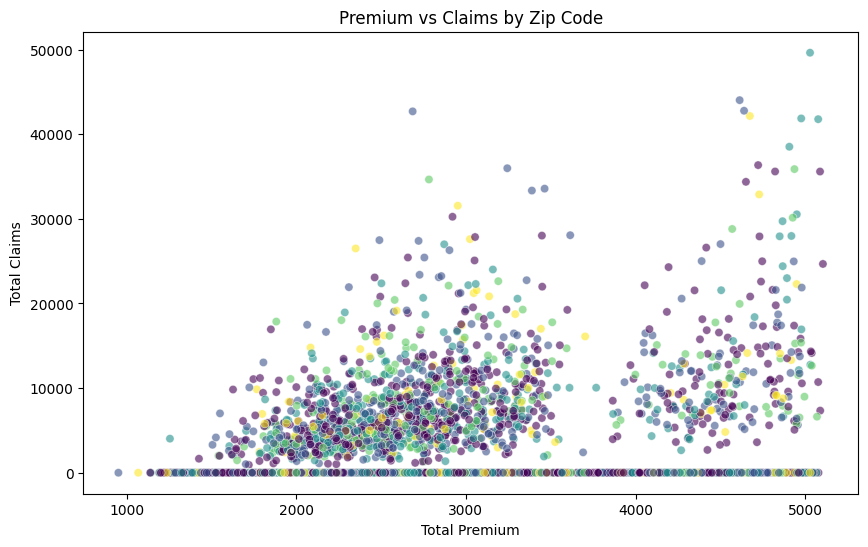

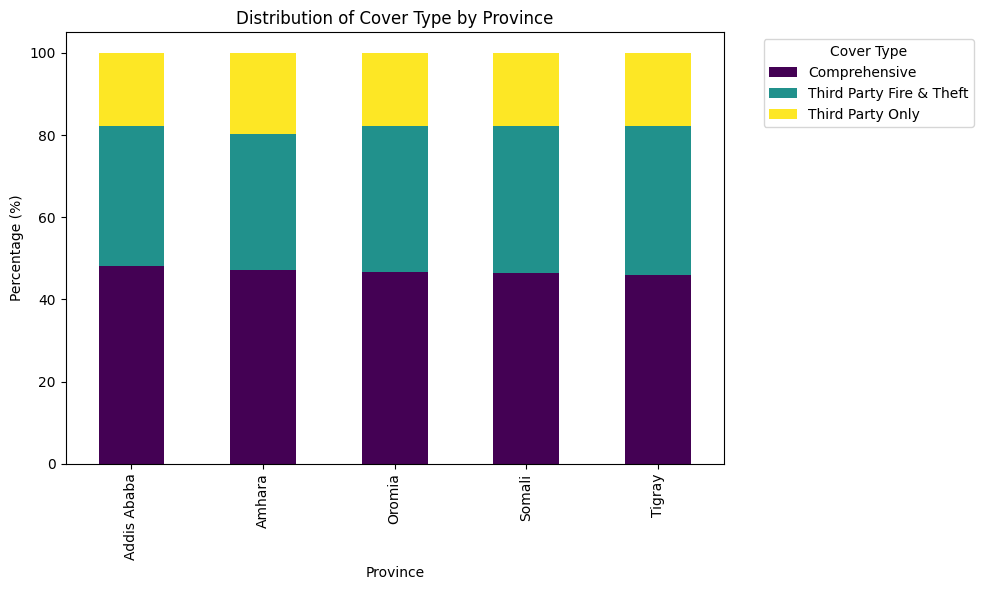

/tmp/ipykernel_15161/1417171024.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_stats.index, rotation=45)


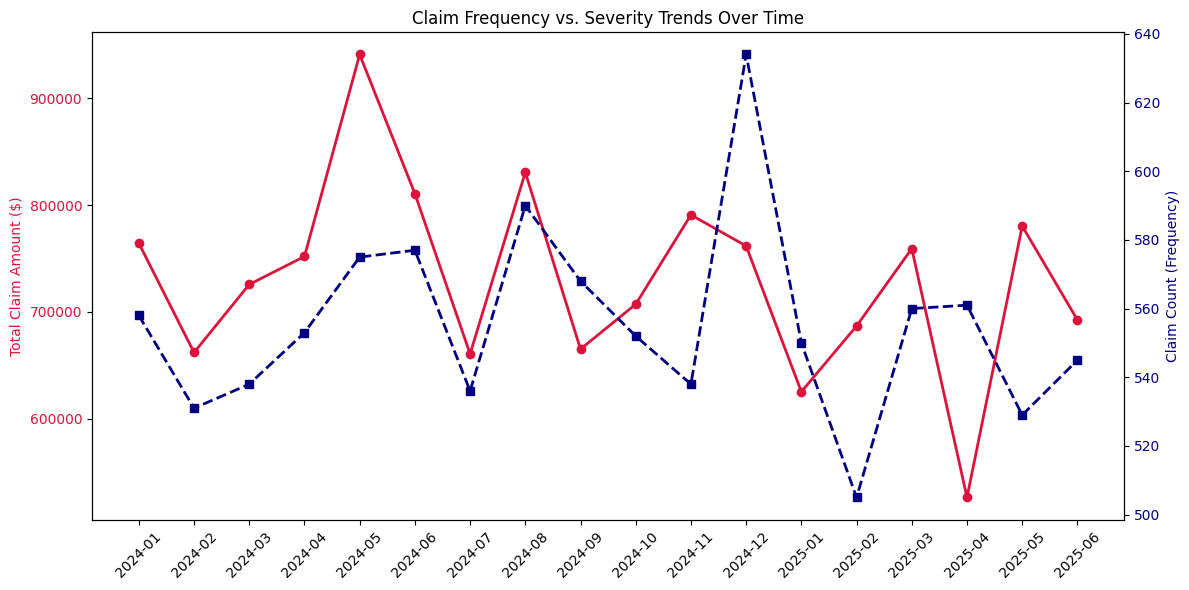

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. MISSING LOSS RATIOS (VehicleType & Gender) ---
vehicle_lr = (df.groupby('VehicleType')['TotalClaims'].sum() / df.groupby('VehicleType')['TotalPremium'].sum()).sort_values(ascending=False)
gender_lr = (df.groupby('Gender')['TotalClaims'].sum() / df.groupby('Gender')['TotalPremium'].sum()).sort_values(ascending=False)

print("Loss Ratio by Vehicle Type:\n", vehicle_lr)
print("\nLoss Ratio by Gender:\n", gender_lr)


# --- 2. BIVARIATE ANALYSIS BY ZIPCODE ---
plt.figure(figsize=(10, 6))
# Using ZipCode for hue/color segmentation
sns.scatterplot(
    data=df, 
    x='TotalPremium', 
    y='TotalClaims', 
    hue='ZipCode', 
    palette='viridis', 
    alpha=0.6
) 
plt.title("Premium vs Claims by Zip Code")
plt.xlabel("Total Premium")
plt.ylabel("Total Claims")
# Hide the legend since 10,000 rows likely mean too many unique zip codes to display cleanly
plt.gca().get_legend().remove() 
plt.show()


# --- 3. GEOGRAPHIC TRENDS (CoverType and AutoMake across Provinces) ---
# Cross-tabulate to see dominant cover types per province (%)
province_cover = pd.crosstab(df['Province'], df['CoverType'], normalize='index') * 100
province_cover.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='viridis')
plt.title("Distribution of Cover Type by Province")
plt.ylabel("Percentage (%)")
plt.xlabel("Province")
plt.legend(title="Cover Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 4. TEMPORAL TRENDS (Frequency vs Severity over 18 Months) ---
# Ensure your TransactionMonth is derived first
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionMonth'] = df['TransactionDate'].dt.to_period('M')

monthly_stats = df.groupby('TransactionMonth').agg(
    Total_Claim_Amount=('TotalClaims', 'sum'),
    Claim_Count=('TotalClaims', 'count')
)
# Convert Period index to string to prevent Matplotlib rendering bugs
monthly_stats.index = monthly_stats.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot Severity (Total Claim Amount) on left axis
ax1.plot(monthly_stats.index, monthly_stats['Total_Claim_Amount'], color='crimson', marker='o', linewidth=2, label='Severity (Total Amount)')
ax1.set_ylabel("Total Claim Amount ($)", color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')

# Plot Frequency (Count of claims) on right axis
ax2.plot(monthly_stats.index, monthly_stats['Claim_Count'], color='navy', marker='s', linewidth=2, linestyle='--', label='Frequency (Count)')
ax2.set_ylabel("Claim Count (Frequency)", color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title("Claim Frequency vs. Severity Trends Over Time")
ax1.set_xticklabels(monthly_stats.index, rotation=45)
fig.tight_layout()
plt.show()
